In [101]:
# !pip install seaborn

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [103]:
diabetes = pd.read_csv("diabetes.csv")

# First look
diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [104]:
diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [105]:
diabetes.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [106]:
(diabetes == 0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

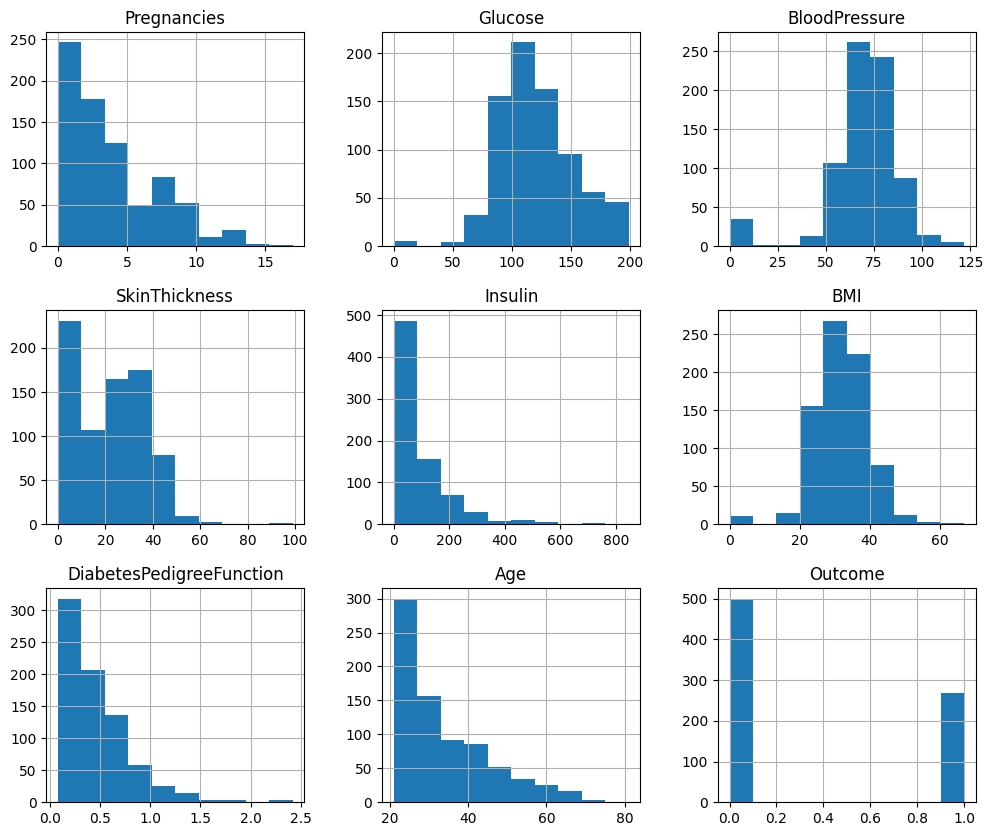

In [107]:
diabetes.hist(figsize=(12,10))
plt.show()

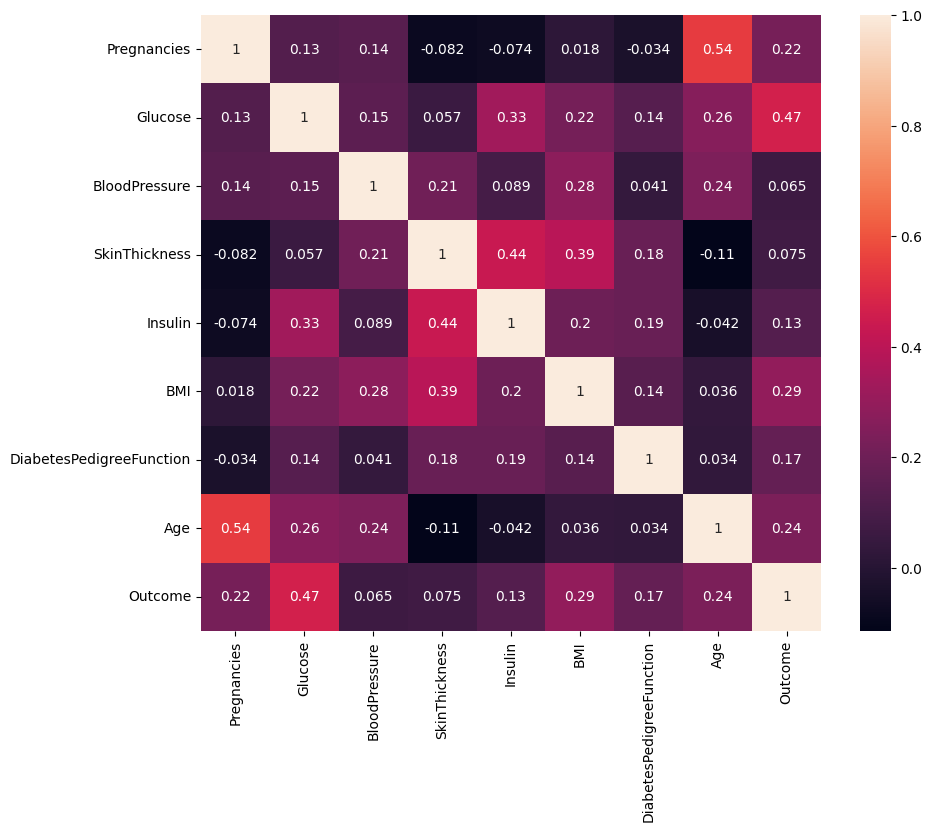

In [108]:
plt.figure(figsize=(10,8))
sns.heatmap(diabetes.corr(), annot=True)
plt.show()

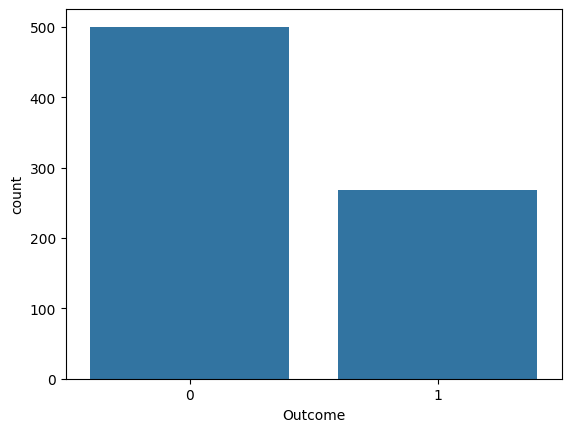

In [109]:
sns.countplot(x='Outcome', data=diabetes)
plt.show()

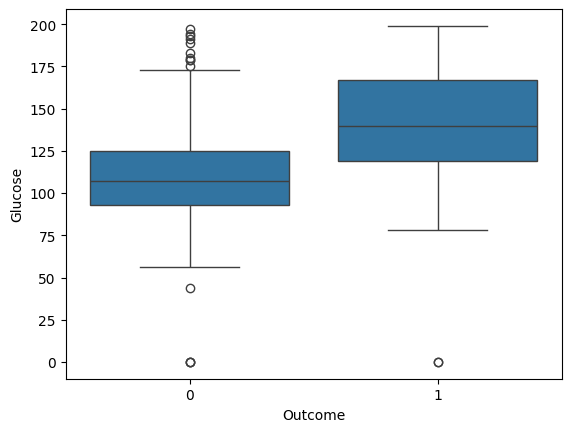

In [110]:
sns.boxplot(x='Outcome', y='Glucose', data=diabetes)
plt.show()

In [111]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


In [112]:
# replacing invalid zeros
cols = ['Glucose', 'BloodPressure', 'BMI', 'Insulin']

diabetes[cols] = diabetes[cols].replace(0, np.nan)
diabetes[cols] = diabetes[cols].fillna(diabetes[cols].median())

In [113]:
# outlier detection 
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[(df[col] >= lower) & (df[col] <= upper)]

for col in ['Glucose', 'BMI', 'Insulin']:
    diabetes = remove_outliers(diabetes, col)

In [114]:
# feature engineering 
diabetes["BMI_Age"] = diabetes["BMI"] * diabetes["Age"]

# Split
X = diabetes.drop("Outcome", axis=1)
y = diabetes["Outcome"]

# Check before scaling
print(X.shape)  # must NOT be (0, n)

# Scale
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

(405, 9)


In [115]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [116]:
from sklearn.svm import SVC
lr_model = LogisticRegression(max_iter=1000)
dt_model = DecisionTreeClassifier()
rf_model= RandomForestClassifier()
svm_model = SVC(probability=True)

In [117]:
# hyperparameter tuning
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 10]
}

grid_rf = GridSearchCV(rf, param_grid, cv=5)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

print("Best RF Params:", grid_rf.best_params_)


Best RF Params: {'max_depth': 10, 'n_estimators': 50}


In [118]:
lr_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)
svm_model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [119]:
# K-FOLD CROSS VALIDATION

# Data ko multiple parts mein divide karte hain
# Har baar different part test banta hai
# Model ka average performance nikalte hain
# Isse overfitting detect hota ha



In [120]:
from sklearn.model_selection import cross_val_score

# Logistic Regression
lr_scores = cross_val_score(lr_model, X_scaled, y, cv=5).mean()

# Decision Tree
dt_scores = cross_val_score(dt_model, X_scaled, y, cv=5).mean()

# Random Forest
rf_scores = cross_val_score(best_rf, X_scaled, y, cv=5).mean()

# SVM
svm_scores = cross_val_score(svm_model, X_scaled, y, cv=5).mean()

print("LR Accuracy:", lr_scores)
print("DT Accuracy:", dt_scores)
print("RF Accuracy:", rf_scores)
print("SVM Accuracy:", svm_scores)

LR Accuracy: 0.7358024691358024
DT Accuracy: 0.6666666666666666
RF Accuracy: 0.7308641975308642
SVM Accuracy: 0.7407407407407407


In [121]:
lr_pred = lr_model.predict(X_test)
dt_pred = dt_model.predict(X_test)
rf_pred = best_rf.predict(X_test)
svm_pred = svm_model.predict(X_test)

In [122]:
from sklearn.metrics import classification_report

print("Logistic Regression\n", classification_report(y_test, lr_pred))
print("Decision Tree\n", classification_report(y_test, dt_pred))
print("Random Forest\n", classification_report(y_test, rf_pred))
print("SVM\n", classification_report(y_test, svm_pred))

Logistic Regression
               precision    recall  f1-score   support

           0       0.69      0.74      0.72        46
           1       0.62      0.57      0.60        35

    accuracy                           0.67        81
   macro avg       0.66      0.66      0.66        81
weighted avg       0.66      0.67      0.66        81

Decision Tree
               precision    recall  f1-score   support

           0       0.66      0.67      0.67        46
           1       0.56      0.54      0.55        35

    accuracy                           0.62        81
   macro avg       0.61      0.61      0.61        81
weighted avg       0.62      0.62      0.62        81

Random Forest
               precision    recall  f1-score   support

           0       0.72      0.72      0.72        46
           1       0.63      0.63      0.63        35

    accuracy                           0.68        81
   macro avg       0.67      0.67      0.67        81
weighted avg       0.68

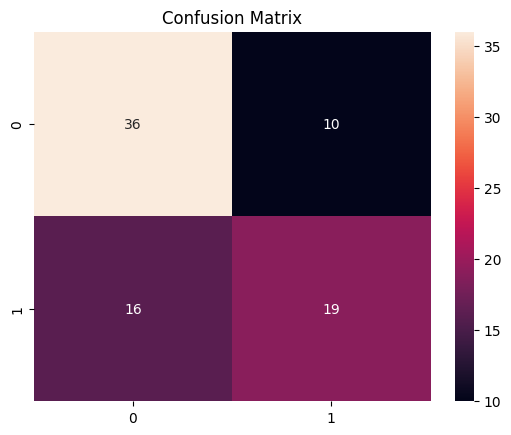

In [123]:
# SVM CM
cm = confusion_matrix(y_test, svm_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

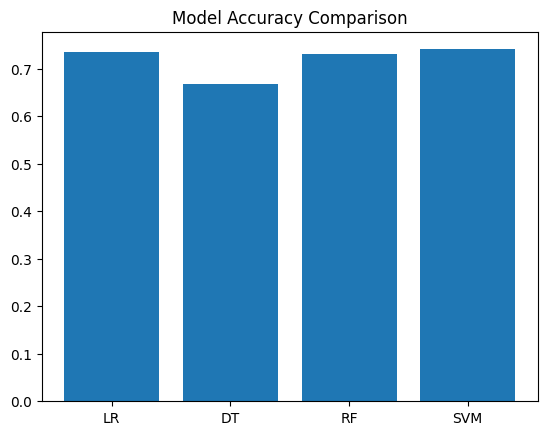

In [124]:

models = ["LR", "DT","RF","SVM"]
scores = [lr_scores.mean(), dt_scores.mean(),rf_scores.mean(), svm_scores.mean()]

plt.bar(models, scores)
plt.title("Model Accuracy Comparison")
plt.show()

In [125]:
# Load data
heart = pd.read_csv("heart_disease_uci.csv")

# Target
Xh = heart.drop("num", axis=1)
yh = heart["num"]

# OPTIONAL (recommended): Convert to binary classification
# 0 = no disease, 1 = disease
yh = (yh > 0).astype(int)

#  Handle categorical data
Xh = pd.get_dummies(Xh, drop_first=True)

#  Handle missing values
Xh = Xh.fillna(Xh.median())

# Split
Xh_train, Xh_test, yh_train, yh_test = train_test_split(
    Xh, yh, test_size=0.2, random_state=42
)

# Model
heart_model = RandomForestClassifier(random_state=42)
heart_model.fit(Xh_train, yh_train)

# Accuracy check
print("Train Accuracy:", heart_model.score(Xh_train, yh_train))
print("Test Accuracy:", heart_model.score(Xh_test, yh_test))

Train Accuracy: 1.0
Test Accuracy: 0.875


In [126]:
def predict_disease(input_data):
    input_df = pd.DataFrame([input_data])
    
    # Encode
    input_df = pd.get_dummies(input_df)
    
    # Align with training columns
    input_df = input_df.reindex(columns=Xh.columns, fill_value=0)
    
    # Predict
    pred = heart_model.predict(input_df)[0]
    prob = heart_model.predict_proba(input_df)[0][1]
    
    return {
        "prediction": "Disease" if pred == 1 else "No Disease",
        "confidence": round(prob * 100, 2)
    }

In [127]:
def get_suggestions(diabetes_result, heart_result, diabetes_prob=None, heart_prob=None):
    suggestions = []

    # Diabetes suggestions
    if diabetes_result == 1:
        suggestions.extend([
            "Reduce sugar and refined carbs",
            "Exercise at least 30 minutes daily",
            "Monitor blood glucose regularly"
        ])

        if diabetes_prob and diabetes_prob > 0.7:
            suggestions.append(" High diabetes risk – consult a doctor")

    # Heart disease suggestions
    if heart_result == 1:
        suggestions.extend([
            "Avoid oily and high-fat foods",
            "Reduce salt intake",
            "Maintain healthy cholesterol levels",
            "Do regular cardio exercise"
        ])

        if heart_prob and heart_prob > 0.7:
            suggestions.append(" High heart risk – medical checkup recommended")

    # Combined condition (VERY IMPORTANT UPGRADE)
    if diabetes_result == 1 and heart_result == 1:
        suggestions.append(" High combined risk – strict diet and regular monitoring required")

    #  Healthy case
    if diabetes_result == 0 and heart_result == 0:
        suggestions.extend([
            "Maintain a balanced diet",
            "Exercise regularly",
            "Get routine health checkups"
        ])

    return suggestions

In [128]:
def predict_health(diabetes_input, heart_input):
    
    # ---- Diabetes Prediction ----
    diabetes_df = pd.DataFrame([diabetes_input])
    diabetes_df = diabetes_df[X.columns]   # enforce order

    diabetes_df = pd.DataFrame(
        scaler.transform(diabetes_df),
        columns=X.columns
    )
    
    diabetes_pred = best_rf.predict(diabetes_df)[0]
    diabetes_prob = best_rf.predict_proba(diabetes_df)[0][1]
    
    
    # ---- Heart Prediction ----
    heart_df = pd.DataFrame([heart_input])
    heart_df = pd.get_dummies(heart_df)
    heart_df = heart_df.reindex(columns=Xh.columns, fill_value=0)
    
    heart_pred = heart_model.predict(heart_df)[0]
    heart_prob = heart_model.predict_proba(heart_df)[0][1]
    
    
    # ---- Suggestions ----
    suggestions = get_suggestions(
        diabetes_pred,
        heart_pred,
        diabetes_prob,
        heart_prob
    )    
    
    # ---- Final Output ----
    result = {
        "diabetes": {
            "prediction": "Diabetic" if diabetes_pred == 1 else "Non-Diabetic",
            "confidence": round(diabetes_prob * 100, 2)
        },
        "heart_disease": {
            "prediction": "At Risk" if heart_pred == 1 else "Healthy",
            "confidence": round(heart_prob * 100, 2)
        },
        "suggestions": suggestions
    }
    
    return result

In [129]:
diabetes_sample = {
    'Pregnancies': 2,
    'Glucose': 120,
    'BloodPressure': 70,
    'SkinThickness': 20,
    'Insulin': 85,
    'BMI': 28.5,
    'DiabetesPedigreeFunction': 0.5,
    'Age': 35,
    'BMI_Age': 28.5 * 35
}

heart_sample = {
    'age': 52,
    'sex': 'Male',
    'cp': 'typical angina',
    'trestbps': 125,
    'chol': 212,
    'fbs': 0,
    'restecg': 'normal',
    'thalach': 168,
    'exang': 0,
    'oldpeak': 1.0,
    'slope': 'upsloping',
    'ca': 0,
    'thal': 'normal'
}

print(predict_health(diabetes_sample, heart_sample))

{'diabetes': {'prediction': 'Non-Diabetic', 'confidence': np.float64(41.13)}, 'heart_disease': {'prediction': 'Healthy', 'confidence': np.float64(31.0)}, 'suggestions': ['Maintain a balanced diet', 'Exercise regularly', 'Get routine health checkups']}


In [130]:
print(type(best_rf))
print(type(heart_model))
print(type(scaler))
print(len(Xh.columns))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
<class 'sklearn.ensemble._forest.RandomForestClassifier'>
<class 'sklearn.preprocessing._data.StandardScaler'>
22


In [131]:
import joblib

# Save Diabetes Model
joblib.dump(best_rf, "diabetes_model.pkl")

# Save Scaler
joblib.dump(scaler, "scaler.pkl")

# Save Heart Model
joblib.dump(heart_model, "heart_model.pkl")

# Save Heart Columns (CRITICAL)
joblib.dump(Xh.columns.tolist(), "heart_columns.pkl")

print(" All models saved successfully!")

 All models saved successfully!


In [132]:
import joblib

joblib.dump(best_rf, "test.pkl")
loaded = joblib.load("test.pkl")

print("Model works:", loaded.predict(X_scaled[:1]))

Model works: [1]
